# Sales Performance Analysis
**Dataset:** Sample Superstore (Kaggle)  
**Objetivo:** Analisar performance de vendas por região, categoria e produto, identificando padrões de lucro e impacto de descontos.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [14]:
df = pd.read_csv("../../data/superstore.csv", encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [15]:
print(f"Shape: {df.shape}")
print(f"\nColunas:\n{df.columns.tolist()}")
print(f"\nTipos de dado:\n{df.dtypes}")
print(f"\nNulos por coluna:\n{df.isnull().sum()}")

Shape: (9994, 21)

Colunas:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Tipos de dado:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Nulos por coluna:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segme

In [16]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [17]:
# Converter datas de texto para datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Criar colunas auxiliares para análise temporal
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Confirmar
print(df["Order Date"].dtype)
df[["Order Date", "Ship Date", "Year", "Month", "YearMonth"]].head()

datetime64[ns]


,Order Date,Ship Date,Year,Month,YearMonth
0,2016-11-08,2016-11-11,2016,11,2016-11
1,2016-11-08,2016-11-11,2016,11,2016-11
2,2016-06-12,2016-06-16,2016,6,2016-06
3,2015-10-11,2015-10-18,2015,10,2015-10
4,2015-10-11,2015-10-18,2015,10,2015-10


## Bloco 3 — Análise de Receita por Região e Categoria

In [18]:
regiao = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
regiao["Profit Margin %"] = (regiao["Profit"] / regiao["Sales"] * 100).round(2)
regiao

,Sales,Profit,Profit Margin %
Region,,,
West,725457.8245,108418.4489,14.94
East,678781.2400,91522.7800,13.48
Central,501239.8908,39706.3625,7.92
South,391721.9050,46749.4303,11.93


In [19]:
categoria = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
categoria["Profit Margin %"] = (categoria["Profit"] / categoria["Sales"] * 100). round(2)
categoria

,Sales,Profit,Profit Margin %
Category,,,
Technology,836154.0330,145454.9481,17.40
Furniture,741999.7953,18451.2728,2.49
Office Supplies,719047.0320,122490.8008,17.04


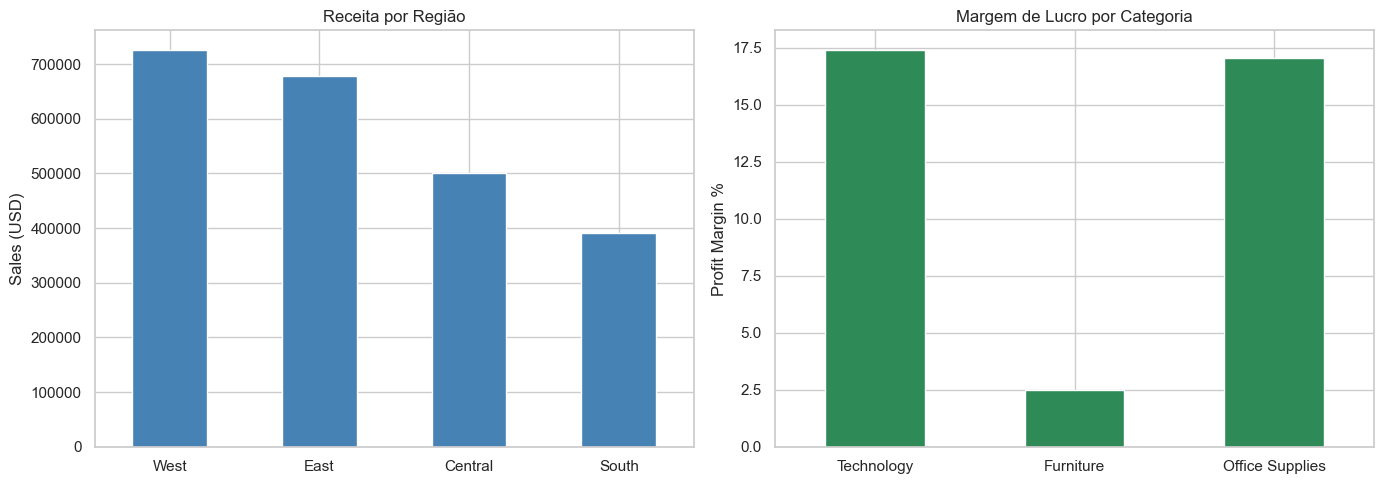

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Receita por Região
regiao["Sales"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Receita por Região")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sales (USD)")
axes[0].tick_params(axis="x", rotation=0)

# Margem por Categoria
categoria["Profit Margin %"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Margem de Lucro por Categoria")
axes[1].set_xlabel("")
axes[1].set_ylabel("Profit Margin %")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Bloco 4 — Tendência Temporal de Vendas

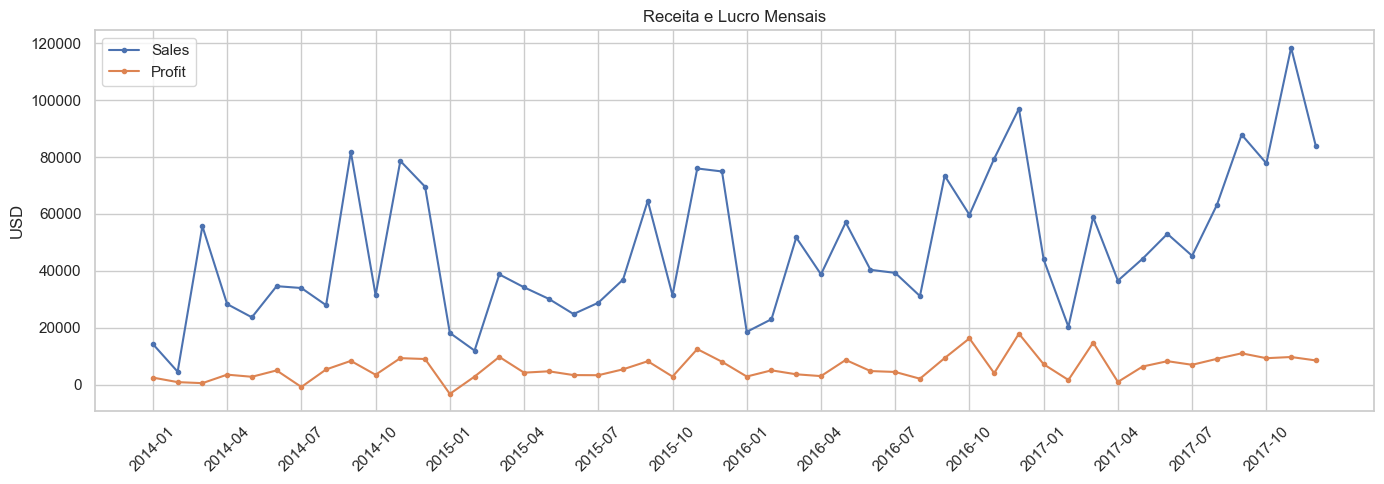

In [25]:
tendencia = df.groupby("YearMonth")[["Sales", "Profit"]].sum()
tendencia.index = tendencia.index.astype(str)  # converte Period para string pro gráfico

tendencia.plot(kind="line", figsize=(14, 5), marker="o", markersize=3)
plt.title("Receita e Lucro Mensais")
plt.xlabel("")
plt.ylabel("USD")
plt.xticks(range(0, len(tendencia), 3), tendencia.index[::3], rotation=45)
plt.tight_layout()
plt.show()

## Bloco 5 — Impacto de Descontos e Performance por Produto

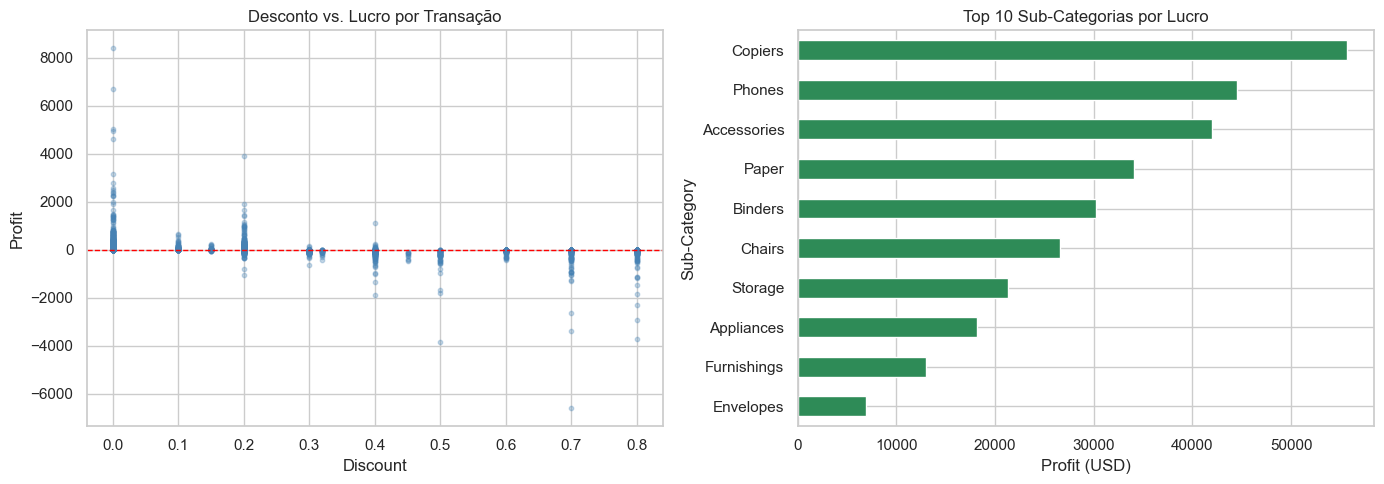

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Desconto vs Lucro
axes[0].scatter(df["Discount"], df["Profit"], alpha=0.3, color="steelblue", s=10)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Desconto vs. Lucro por Transação")
axes[0].set_xlabel("Discount")
axes[0].set_ylabel("Profit")

# Top 10 sub-categorias por lucro
top_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=True).tail(10)
top_subcat.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Top 10 Sub-Categorias por Lucro")
axes[1].set_xlabel("Profit (USD)")

plt.tight_layout()
plt.show()

In [27]:
desconto_cat = df.groupby("Category")[["Discount", "Profit"]].mean().round(3)
desconto_cat["Profit Margin %"] = (
    df.groupby("Category")["Profit"].sum() / 
    df.groupby("Category")["Sales"].sum() * 100
).round(2)
desconto_cat.columns = ["Avg Discount", "Avg Profit per Line", "Profit Margin %"]
desconto_cat.sort_values("Avg Discount", ascending=False)

,Avg Discount,Avg Profit per Line,Profit Margin %
Category,,,
Furniture,0.174,8.699,2.49
Office Supplies,0.157,20.327,17.04
Technology,0.132,78.752,17.40


## Conclusões

- **Região West** lidera em receita (USD 725k) e margem (14.9%)
- **Furniture** apresenta margem crítica de 2.49% — o maior desconto médio da base (17.4%) é o principal fator
- **Descontos acima de 40%** resultam sistematicamente em lucro negativo
- **Sazonalidade clara**: picos de vendas em novembro/dezembro, queda abrupta em janeiro
- **Technology** tem o melhor desempenho combinado: margem de 17.4% com ticket médio alto (USD 78 de lucro por linha)

### Próximos passos sugeridos
- Analisar quais sub-categorias de Furniture concentram os maiores descontos
- Investigar performance por segmento de cliente (Consumer, Corporate, Home Office)
- Avaliar se a sazonalidade varia por região